In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"Clustering_data.csv")
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [3]:
df.isnull().sum()


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [4]:
df.dtypes

Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
Customer_Segment          int64
dtype: object

In [5]:
df.shape

(178, 14)

In [6]:
X = df.drop("Customer_Segment", axis=1).values
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [7]:
def kmeans(X, K, iter=100):
    ctrd = X[np.random.choice(len(X), K, replace=False)]
    
    for i in range(iter):
        cluster = [[] for _ in range(K)]
        
        for p in X:
            dist = [np.linalg.norm(p - c) for c in ctrd]
            c_index = np.argmin(dist)
            cluster[c_index].append(p)

        ctrd2 = []
        for j, c in enumerate(cluster):
            if len(c) == 0:
                ctrd2.append(ctrd[j])
            else:
                ctrd2.append(np.mean(c, axis=0))
        
        ctrd2 = np.array(ctrd2)

        if np.allclose(ctrd, ctrd2):
            break
        
        ctrd = ctrd2
    
    return ctrd, cluster


In [8]:
ctrd, clusters = kmeans(X, K=3)

def get_labels(X, centroids):
    labels = []
    for p in X:
        dist = [np.linalg.norm(p - c) for c in centroids]
        labels.append(np.argmin(dist))
    return np.array(labels)

labels = get_labels(X, ctrd)

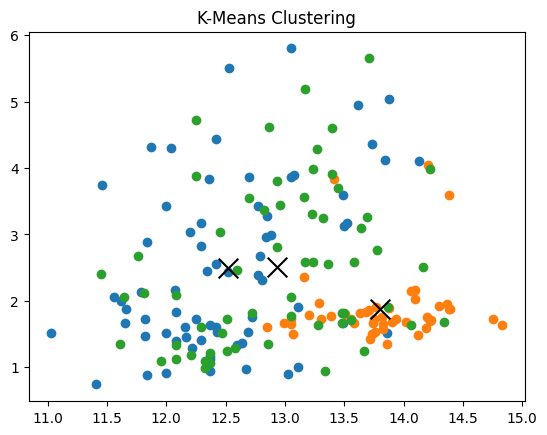

In [9]:
import matplotlib.pyplot as plt

labels = get_labels(X, ctrd)

for i in range(len(ctrd)):
    pts = X[labels == i]
    plt.scatter(pts[:, 0], pts[:, 1])

plt.scatter(ctrd[:, 0], ctrd[:, 1], 
            c='black', marker='x', s=200)

plt.title("K-Means Clustering")
plt.show()

In [10]:
def compute_wcss(ctrd, cluster):
    wcss = 0
    for i, c in enumerate(cluster):
        for p in c:
            wcss += np.linalg.norm(p - ctrd[i])**2
    return wcss

In [11]:
w_values = []
r= range(1, 20)

for K in r:
    cd, cr = kmeans(X, K)
    w = compute_wcss(cd, cr)
    w_values.append(w)
w_values

[np.float64(17592296.383508477),
 np.float64(4545746.292099377),
 np.float64(2370689.6867829678),
 np.float64(1341379.5700647028),
 np.float64(1061573.2774376583),
 np.float64(683806.0589670823),
 np.float64(414752.8738392505),
 np.float64(329655.41532503424),
 np.float64(511271.9795347765),
 np.float64(247451.3703399044),
 np.float64(411400.7798929628),
 np.float64(220616.6429219634),
 np.float64(211361.17241907716),
 np.float64(153541.90706627097),
 np.float64(146205.42415188634),
 np.float64(139308.3433589578),
 np.float64(135321.38602753374),
 np.float64(124474.82207028942),
 np.float64(120695.76967922693)]

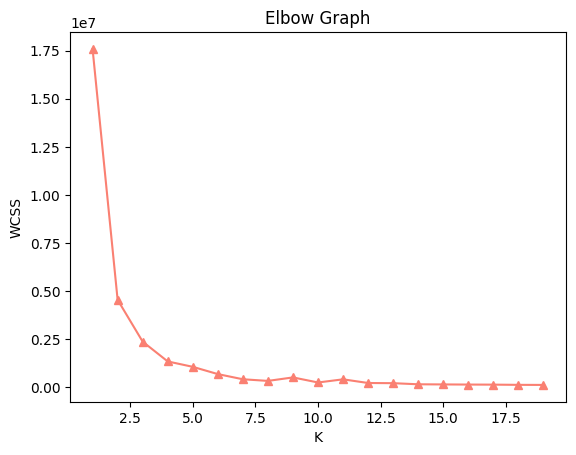

In [12]:
plt.plot(r, w_values, marker='^', color="salmon")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Graph")
plt.show()